# Математическая статистика для анализа больших данных.
## Задание 2
### Асимпотические доверительные интервалы. Метод бутстрепа

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [3]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from skimage.transform import resize
import scipy.stats as sps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Задача 1

Пусть $x_1, \dots, x_n$ &mdash; реализация выборки, $X^{*}_1, X^{*}_2, \dots, X^{*}_n$ &mdash; построенная по ней бутстрепная выборка. С какой вероятностью элемент $x_i$ исходной выборки попадёт в бутстрепную? Посчитайте среднее число уникальных элементов в бутстрепной выборке, если в исходной выборке все элементы различны? К какой фунции от $n$ стремится это количество при $n \rightarrow \infty$?

### 1. Вероятность попадания элемента в бутстрепную выборку

При построении бутстрепной выборки мы выбираем $n$ элементов с возвращением из исходной выборки размера $n$. На каждом шаге элемент $x_i$ может быть выбран с вероятностью $\frac{1}{n}$.

Вероятность того, что элемент $x_i$ не выбран в одном из выборов:

$$
P(\text{элемент } x_i \text{ не выбран за один раз}) = 1 - \frac{1}{n} = \frac{n-1}{n}.
$$

Вероятность того, что элемент $x_i$ не попал в бутстрепную выборку (не выбран ни разу в $n$ независимых выборах):

$$
P(\text{элемент } x_i \text{ не попал в бутстрепную выборку}) = \left( \frac{n-1}{n} \right)^n.
$$

Вероятность того, что элемент $x_i$ попал в бутстрепную выборку:

$$
P(\text{элемент } x_i \text{ попал в бутстрепную выборку}) = 1 - \left( \frac{n-1}{n} \right)^n.
$$

---

### 2. Среднее число уникальных элементов в бутстрепной выборке

Так как все элементы $x_i$ различны, то математическое ожидание числа уникальных элементов в бутстрепной выборке равно сумме вероятностей попадания каждого элемента:

$$
E[\text{число уникальных элементов}] = n \cdot P(\text{элемент } x_i \text{ попал в бутстрепную выборку}) = n \left( 1 - \left( \frac{n-1}{n} \right)^n \right).
$$

---

### 3. Предел при $n \to \infty$

Рассмотрим предел:

$$
\lim_{n \to \infty} \left( \frac{n-1}{n} \right)^n = \lim_{n \to \infty} \left( 1 - \frac{1}{n} \right)^n = e^{-1}.
$$

Тогда:

$$
\lim_{n \to \infty} E[\text{число уникальных элементов}] = n \left( 1 - e^{-1} \right)
$$



### Задача 2

 В данном задании сравним асимптотические доверительные интервалы, построенные для параметра $\alpha$ в распределении $\Gamma(\alpha, \beta)$, при известном и не известном $\beta$.

 Опишем задачу подробнее:

1. Используя материал лекции выпишите доверительный интервал для $\alpha$ уровня доверия 0.95 при известном $\beta$.

*Подсказка: можно использовать, что если $\xi \sim N(a,\sigma^2)$, то для константы c справедливо, что $\xi - c \sim N(a - c,\sigma^2)$, а $c\xi \sim N(a,\sigma^2 c^2)$.*

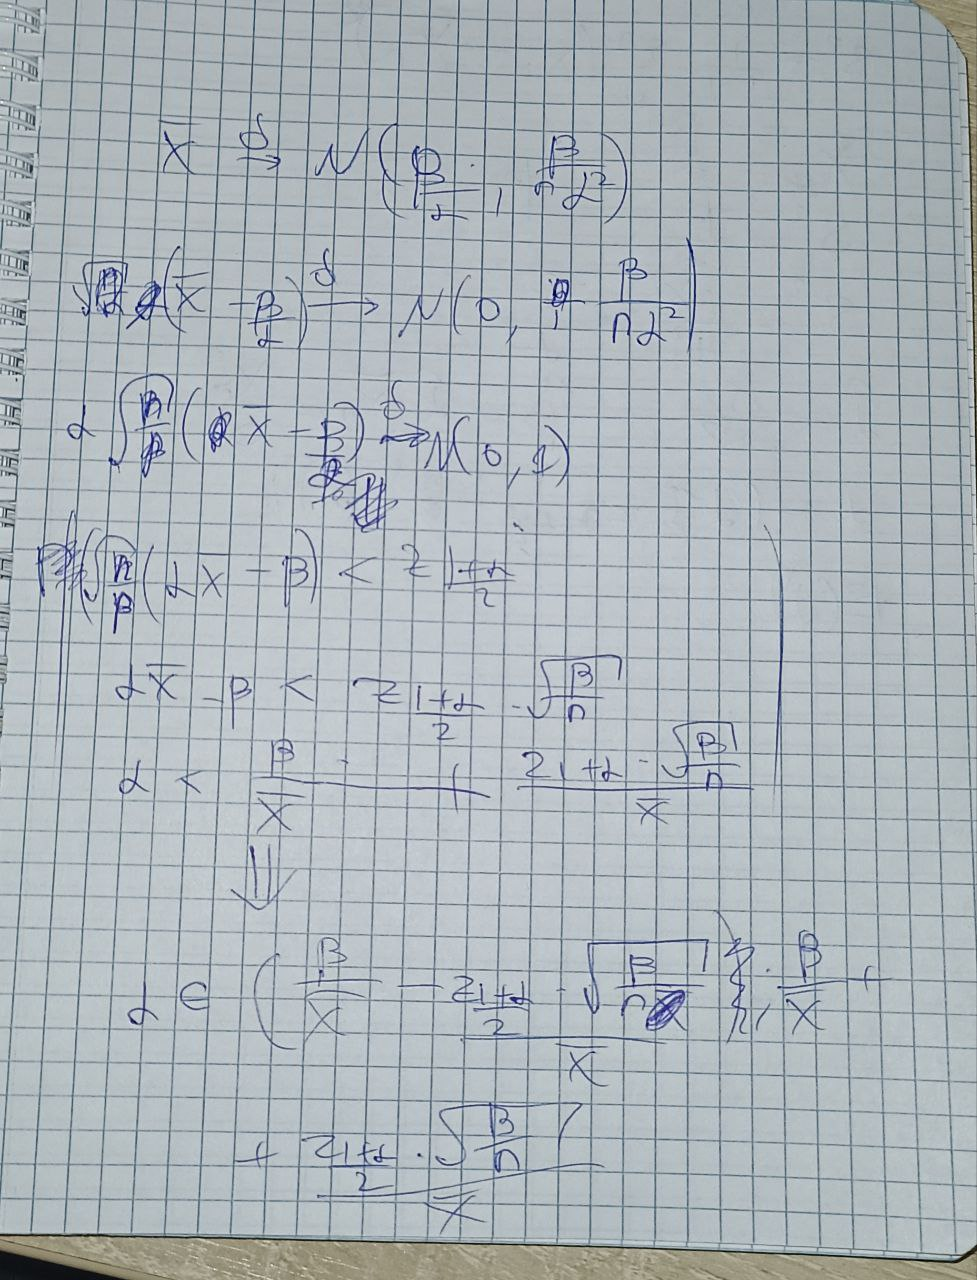

2. Для случая с неизвестным $\beta$ используйте доверительный интервал ниже:

 $$ \alpha \in \left(\frac{\overline{X}}{S^2} \pm \frac{z_{(1 + \alpha) / 2}}{\sqrt{n}}\frac{\overline{X}}{S^2} \sqrt{2 + 3\frac{S^2}{(\overline{X})^2}} \right) $$

3. Для отрисовки реализуйте функцию ниже:

In [4]:
def draw_confidence_interval(
    left, right, estimation=None, sample=None,
    ylim=(None, None), color_estimation='#FF3300', color_interval='#00CC66',
    color_sample='#0066FF', label_estimation='Оценка'
):
    '''
    Рисует доверительный интервал и оценку в зависимости от размера выборки.

    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimation: оценки (в зависимости от n)
    :param sample: выборка
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценки
    :param color_interval: цвет интервала
    :param color_sample: цвет выборки
    :param label_estimation: подпись для оценки
    '''

    n = len(left)
    x = np.arange(1, n+1)
    plt.fill_between(x, left, right, color=color_interval, alpha=0.3, label='Доверительный интервал')
    if estimation is not None:
        plt.plot(x, estimation, color=color_estimation, label=label_estimation)
    if sample is not None:
        plt.scatter(x, sample[:n], color=color_sample, s=10, label='Выборка')
    plt.xlabel('Размер выборки')
    plt.ylabel('Значение параметра α')
    if ylim[0] is not None or ylim[1] is not None:
        plt.ylim(ylim)
    plt.legend()
    plt.grid(True)


4. Сгенерируйте выборку $X_1, ... X_{100}$ из распределения $\Gamma(3, 2)$.

In [5]:
n = 100
alpha_true = 3
beta_true = 2
sample = sps.gamma(a=alpha_true, scale=beta_true).rvs(size=n)

5. Вычислите интервалы по формулам и отрисуйте на **одном** графике, используя функцию из пункта 3.

*Подсказка:*

- *Для вычисления квантилей распределения из `scipy.stats` используйте функцию `ppf`.*
- *Чтобы не делать цикл по n для вычисления каждого интервала в зависимости от размера выборки, используйте функцию `np.cumsum(array, axis=-1)`.*

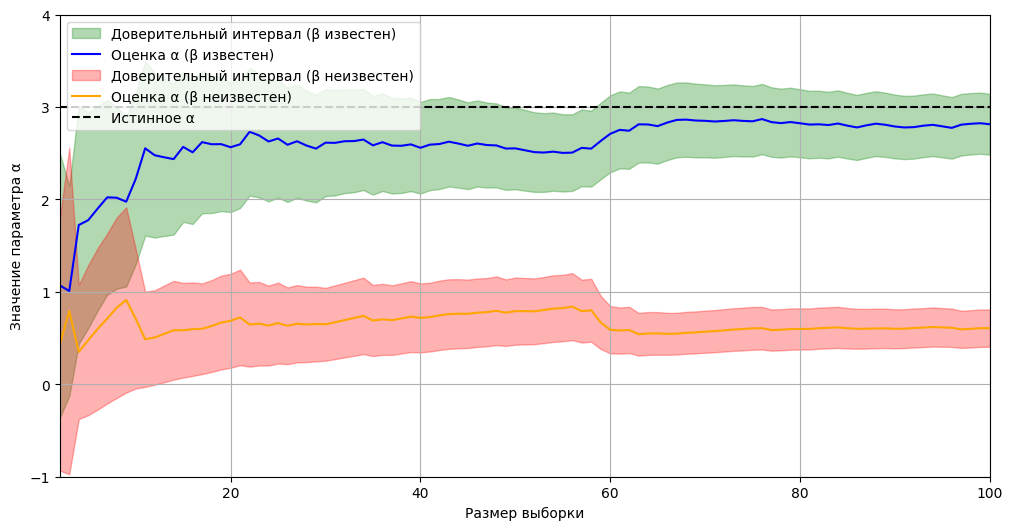

In [13]:
n_values = np.arange(2, n+1)
sample_cumsum = np.cumsum(sample)
sample_cumsum2 = np.cumsum(sample**2)

mean_n = sample_cumsum[1:] / n_values
S2_n = (sample_cumsum2[1:] - n_values * mean_n ** 2) / (n_values - 1)

gamma = 0.95
z = sps.norm.ppf((1 + gamma) / 2)

alpha_hat_known = mean_n / beta_true
SE_known = np.sqrt(alpha_hat_known / n_values)
CI_known_left = alpha_hat_known - z * SE_known
CI_known_right = alpha_hat_known + z * SE_known

alpha_hat_unknown = mean_n / S2_n
temp = np.sqrt(2 + 3 * (S2_n / mean_n**2))
SE_unknown = alpha_hat_unknown * temp / np.sqrt(n_values)
CI_unknown_left = alpha_hat_unknown - z * SE_unknown
CI_unknown_right = alpha_hat_unknown + z * SE_unknown

plt.figure(figsize=(12, 6))
x = n_values

plt.fill_between(x, CI_known_left, CI_known_right, color='green', alpha=0.3, label='Доверительный интервал (β известен)')
plt.plot(x, alpha_hat_known, color='blue', label='Оценка α (β известен)')

plt.fill_between(x, CI_unknown_left, CI_unknown_right, color='red', alpha=0.3, label='Доверительный интервал (β неизвестен)')
plt.plot(x, alpha_hat_unknown, color='orange', label='Оценка α (β неизвестен)')

plt.hlines(y=alpha_true, xmin=2, xmax=n, color='black', linestyle='--', label='Истинное α')

plt.xlabel('Размер выборки')
plt.ylabel('Значение параметра α')
plt.legend()
plt.xlim(2, n)
plt.ylim(-1, 4)
plt.grid(True)
plt.show()


Сравните полученные интервалы и поясните наблюдаемый эффект.

**Вывод:** Наличие информации о параметре $\beta$ существенно влияет на точность оценки параметра $\alpha$ и ширину доверительного интервала. При известном $\beta$ мы получаем более точные оценки и узкие интервалы. В случае неизвестного $\beta$ дополнительная неопределённость приводит к более широким интервалам, но с увеличением размера выборки эта неопределённость снижается, и оценки становятся точнее.


### Задача 3

Дана выборка $X=(1, 9, 0, 1, 4)$. Посчитайте оценку дисперсии статистики $\overline{X \sqrt{X}}$ c помощью бутстрепа. Реализуйте функцию для генерации бутстрепных выборок без использования циклов. Какое количество бутстрепных выборок $B$ стоит взять?